# CDMX antes, durante y después del COVID-19
## Notebook 00 — Problemática, plan de análisis y datasets

**Proyecto de minería de datos · Fase 1: recolección y limpieza**

Este notebook presenta el contexto del proyecto:
1. La **problemática** y la pregunta de investigación.
2. **Qué se analizará**: dimensiones, variables, periodos y unidades de análisis.
3. Los **datasets** que se usarán, con una verificación en vivo de que siguen disponibles en el portal de datos abiertos.
4. Una **primera exploración** de la afluencia del Metro para ilustrar el fenómeno.

> El detalle completo está en `CONTEXTO.md` y en el informe `informe/main.pdf`.

## 1. Problemática

La pandemia de COVID-19 provocó un choque abrupto sobre la vida urbana de la Ciudad de México:

- **28-feb-2020:** primer caso confirmado en México.
- **23-mar-2020:** inicio de la *Jornada Nacional de Sana Distancia*, con cierre de escuelas, actividades no esenciales y teletrabajo.
- **2020–2022:** semáforo epidemiológico, reapertura gradual y vacunación.

Este choque cambió **cómo se mueve la gente**, **qué delitos ocurren y dónde**, y **cuánta actividad económica hay**. Sin embargo, los datos para medirlo tienen tres problemas:

| Problema | Ejemplo |
|---|---|
| **Dispersión** | Gobierno CDMX, FGJ, SSC, C5, INEGI, IMSS y Secretaría de Salud publican por separado |
| **Granularidad distinta** | Metro: diario por estación · Carpetas FGJ: por evento con coordenadas · ITAEE: trimestral por entidad |
| **Calidad heterogénea** | Texto mal codificado, cambios de catálogo (PGJ → FGJ), cierres de líneas, series que empiezan en 2020 |

No existe una base integrada que permita comparar las tres dimensiones sobre el mismo eje de tiempo y territorio.

### Pregunta de investigación
> **¿Cómo cambiaron los patrones de movilidad, seguridad y actividad económica de la Ciudad de México durante la pandemia de COVID-19, y qué diferencias se observan en su recuperación posterior respecto al periodo previo a 2020?**

### Objetivo de esta fase
Construir un **conjunto de datos integrado, limpio y documentado** que sirva de insumo a un modelo predictivo en la siguiente fase.

## 2. Qué se analizará

### 2.1 Dimensiones y variables
| Dimensión | Qué se mide | Variables principales |
|---|---|---|
| **Movilidad** | Uso del transporte público y privado | Afluencia de Metro, Metrobús, STE, RTP y Ecobici; tránsito vehicular; hechos de tránsito |
| **Seguridad** | Delitos denunciados, emergencias y percepción | Carpetas de investigación por tipo de delito, víctimas, llamadas al 911, percepción de inseguridad (ENSU) |
| **Actividad económica** | Empleo y actividad productiva | Asegurados en el IMSS, ocupación y desocupación (ENOE), ITAEE, unidades económicas (DENUE), ocupación hotelera |
| **Pandemia** (control) | Intensidad del COVID-19 | Casos, positividad, hospitalización, color del semáforo |

### 2.2 Periodos

In [1]:
import pandas as pd

PERIODOS = pd.DataFrame([
    ("Pre-pandemia (línea base)", "2016-01-01", "2020-02-29", "Tendencia y estacionalidad normal"),
    ("Choque / confinamiento",    "2020-03-01", "2021-06-30", "Caída; semáforo rojo/naranja"),
    ("Transición",                "2021-07-01", "2022-12-31", "Reapertura gradual, vacunación"),
    ("Post-pandemia",             "2023-01-01", None,         "Recuperación / nueva normalidad"),
], columns=["periodo", "inicio", "fin", "uso"])
PERIODOS["inicio"] = pd.to_datetime(PERIODOS["inicio"])
PERIODOS["fin"] = pd.to_datetime(PERIODOS["fin"])
PERIODOS

,periodo,inicio,fin,uso
0,Pre-pandemia (línea base),2016-01-01,2020-02-29,Tendencia y estacionalidad normal
1,Choque / confinamiento,2020-03-01,2021-06-30,Caída; semáforo rojo/naranja
2,Transición,2021-07-01,2022-12-31,"Reapertura gradual, vacunación"
3,Post-pandemia,2023-01-01,NaT,Recuperación / nueva normalidad


### 2.3 Unidades de análisis
- **Tiempo:** diario donde exista; la base integrada se agrega a **semana** y **mes**.
- **Territorio:** **alcaldía** (16, con clave INEGI `09002`–`09017`); colonia o estación solo cuando el dato lo permita.

### 2.4 Hipótesis
- **H1.** La movilidad en transporte masivo cayó más del 50 % en abril–mayo de 2020 y no se recuperó al ritmo del tránsito vehicular.
- **H2.** Los delitos patrimoniales en vía pública cayeron junto con la movilidad; la violencia familiar no bajó.
- **H3.** El empleo formal se recuperó antes que la movilidad en transporte público (teletrabajo).
- **H4.** La recuperación fue desigual entre alcaldías centrales y periféricas.

### 2.5 Variables objetivo para la fase predictiva
- Afluencia mensual en transporte público.
- Delitos de alto impacto por alcaldía y mes.
- Asegurados en el IMSS en la CDMX por mes.
- **Índice de recuperación** = valor observado / valor esperado sin pandemia (contrafactual con la tendencia pre-2020).

## 3. Datasets

Catálogo de fuentes. Las que vienen del **Portal de Datos Abiertos de la CDMX** (`datos.cdmx.gob.mx`) se identifican con su *id* CKAN, lo que permite consultarlas por API.

In [2]:
CATALOGO = pd.DataFrame([
    # dimension, dataset, institucion, granularidad, id CKAN (portal CDMX) o URL externa
    ("Movilidad", "Afluencia diaria del Metro", "STC Metro", "día × estación", "afluencia-diaria-del-metro-cdmx"),
    ("Movilidad", "Afluencia diaria de Metrobús", "Metrobús", "día × línea", "afluencia-diaria-de-metrobus-cdmx"),
    ("Movilidad", "Afluencia diaria STE (Trolebús, Tren Ligero, Cablebús)", "STE", "día × línea", "afluencia-diaria-servicio-de-transportes-electricos"),
    ("Movilidad", "Afluencia diaria RTP", "RTP", "día × ruta", "afluencia-diaria-de-la-red-de-transporte-de-pasajeros"),
    ("Movilidad", "Afluencia preliminar en transporte público", "SEMOVI", "día × sistema", "afluencia-preliminar-en-transporte-publico"),
    ("Movilidad", "Viajes Ecobici", "Ecobici", "viaje", "afluencia-diaria-del-sistema-ecobici"),
    ("Movilidad", "Movilidad histórico COVID-19", "Gobierno CDMX", "día/semana (índices)", "movilidad-historico-covid-19"),
    ("Movilidad", "Hechos de tránsito SSC (serie ampliada)", "SSC", "evento", "hechos-de-transito-reportados-por-ssc-base-ampliada-no-comparativa"),
    ("Movilidad", "Hechos de tránsito SSC (serie comparable, solo 2018-2019)", "SSC", "evento", "hechos-de-transito-reportados-por-ssc-base-comparativa"),
    ("Movilidad", "GTFS estático", "SEMOVI", "estático", "gtfs"),
    ("Movilidad", "Google Community Mobility Reports", "Google", "día × entidad", "https://www.google.com/covid19/mobility/"),
    ("Seguridad", "Carpetas de investigación FGJ", "FGJ", "evento georreferenciado", "carpetas-de-investigacion-fgj-de-la-ciudad-de-mexico"),
    ("Seguridad", "Víctimas en carpetas FGJ", "FGJ", "víctima", "victimas-en-carpetas-de-investigacion-fgj"),
    ("Seguridad", "Llamadas al 911", "C5", "llamada", "llamadas-numero-de-atencion-a-emergencias-911"),
    ("Seguridad", "Incidencia delictiva municipal", "SESNSP", "mes × municipio", "https://www.gob.mx/sesnsp/acciones-y-programas/datos-abiertos-de-incidencia-delictiva"),
    ("Seguridad", "ENSU (percepción de inseguridad)", "INEGI", "trimestre × ciudad", "https://www.inegi.org.mx/programas/ensu/"),
    ("Seguridad", "ENVIPE (victimización)", "INEGI", "año × entidad", "https://www.inegi.org.mx/programas/envipe/"),
    ("Economía", "Puestos de trabajo asegurados", "IMSS", "mes × municipio × sector", "http://datos.imss.gob.mx/"),
    ("Economía", "ENOE / ETOE", "INEGI", "trimestre × entidad", "https://www.inegi.org.mx/programas/enoe/15ymas/"),
    ("Economía", "ITAEE", "INEGI", "trimestre × entidad", "https://www.inegi.org.mx/temas/itaee/"),
    ("Economía", "DENUE", "INEGI", "establecimiento", "https://www.inegi.org.mx/app/descarga/?ti=6"),
    ("Economía", "Directorio de unidades económicas CDMX", "Portal CDMX", "establecimiento", "directorio-estadistico-de-unidades-economicas-ciudad-de-mexico"),
    ("Economía", "Seguro de desempleo CDMX", "STyFE", "por revisar", "solicitudes-seguro-de-desempleo"),
    ("Economía", "Ocupación hotelera", "SECTUR CDMX", "mes", "ocupacion-hotelera-en-la-ciudad-de-mexico"),
    ("Economía", "Monitor Estadístico CDMX", "Gobierno CDMX", "por revisar", "indicadores-monitor-estadistico-de-la-ciudad-de-mexico"),
    ("Pandemia", "Casos, pruebas y positividad", "Portal CDMX", "día", "total-de-pruebas-total-de-positivos-y-tasa-de-positividad"),
    ("Pandemia", "Base SINAVE COVID-19", "SINAVE", "caso", "base-covid-sinave"),
    ("Pandemia", "Casos por colonia", "SINAVE", "colonia", "covid-19-sinave-ciudad-de-mexico-a-nivel-colonia"),
    ("Pandemia", "Capacidad hospitalaria ZMVM", "Portal CDMX", "día × hospital", "capacidad-hospitalaria"),
    ("Pandemia", "Semáforo epidemiológico", "Secretaría de Salud (compilación semaforos)", "semana × entidad", "https://github.com/Bisaloo/semaforos"),
], columns=["dimension", "dataset", "institucion", "granularidad", "fuente"])

CATALOGO["portal_cdmx"] = ~CATALOGO["fuente"].str.startswith("http")

# Selección final (26-sep-2026): 8 datasets = 6 principales + 2 de control (COVID y semáforo).
# Ecobici se cambió por los hechos de tránsito: complementan al Metro (tránsito vehicular, datos por alcaldía).
# Descartados: Ecobici, 911, ENOE, SESNSP, DENUE (sus archivos siguen en data/raw/).
SELECCIONADOS = {
    "Afluencia diaria del Metro", "Afluencia diaria de Metrobús",
    "Hechos de tránsito SSC (serie ampliada)", "Carpetas de investigación FGJ",
    "Puestos de trabajo asegurados", "Ocupación hotelera",
    "Casos, pruebas y positividad", "Semáforo epidemiológico",
}
CATALOGO["seleccionado"] = CATALOGO["dataset"].isin(SELECCIONADOS)
CATALOGO.groupby("dimension")["seleccionado"].agg(total="size", seleccionados="sum")

,total,seleccionados
dimension,,
Economía,8,2
Movilidad,11,3
Pandemia,5,2
Seguridad,6,1


De las 29 fuentes identificadas se hizo una primera selección de 14 y, después de descargarlas y revisarlas, una **selección final de 8**: seis principales (Metro, Metrobús, hechos de tránsito, carpetas FGJ, IMSS y ocupación hotelera) y dos de control (casos COVID y semáforo). Los hechos de tránsito se prefirieron sobre Ecobici porque complementan las debilidades del Metro: miden el tránsito vehicular y tienen datos por alcaldía. Se descartaron Ecobici, 911, ENOE, SESNSP y DENUE (ver `CONTEXTO.md` §3.0.0).

In [3]:
CATALOGO[CATALOGO.seleccionado][["dimension", "dataset", "institucion", "granularidad"]]

,dimension,dataset,institucion,granularidad
0,Movilidad,Afluencia diaria del Metro,STC Metro,día × estación
1,Movilidad,Afluencia diaria de Metrobús,Metrobús,día × línea
7,Movilidad,Hechos de tránsito SSC (serie ampliada),SSC,evento
11,Seguridad,Carpetas de investigación FGJ,FGJ,evento georreferenciado
17,Economía,Puestos de trabajo asegurados,IMSS,mes × municipio × sector
23,Economía,Ocupación hotelera,SECTUR CDMX,mes
25,Pandemia,"Casos, pruebas y positividad",Portal CDMX,día
29,Pandemia,Semáforo epidemiológico,Secretaría de Salud (compilación semaforos),semana × entidad


### 3.1 Verificación en vivo contra el portal CDMX
Se consulta la API CKAN (`package_show`) de cada dataset del portal para confirmar que existe, cuándo se actualizó y cuántos archivos ofrece.

In [4]:
import requests

CKAN = "https://datos.cdmx.gob.mx/api/3/action/package_show"

def info_ckan(pid):
    try:
        r = requests.get(CKAN, params={"id": pid}, timeout=30).json()["result"]
        csvs = [x for x in r["resources"] if (x.get("format") or "").upper() == "CSV"]
        return pd.Series({"existe": True,
                          "actualizado": r["metadata_modified"][:10],
                          "n_recursos": len(r["resources"]),
                          "n_csv": len(csvs)})
    except Exception as e:
        return pd.Series({"existe": False, "actualizado": None, "n_recursos": 0, "n_csv": 0})

portal = CATALOGO[CATALOGO.portal_cdmx].copy()
portal = portal.join(portal["fuente"].apply(info_ckan))
portal[["dimension", "dataset", "seleccionado", "existe", "actualizado", "n_recursos", "n_csv"]]

,dimension,dataset,seleccionado,existe,actualizado,n_recursos,n_csv
0,Movilidad,Afluencia diaria del Metro,True,False,NaN,0,0
1,Movilidad,Afluencia diaria de Metrobús,True,False,NaN,0,0
2,Movilidad,"Afluencia diaria STE (Trolebús, Tren Ligero, C...",False,False,NaN,0,0
3,Movilidad,Afluencia diaria RTP,False,True,2026-09-04,2,2
4,Movilidad,Afluencia preliminar en transporte público,False,False,NaN,0,0
5,Movilidad,Viajes Ecobici,False,False,NaN,0,0
6,Movilidad,Movilidad histórico COVID-19,False,False,NaN,0,0
7,Movilidad,Hechos de tránsito SSC (serie ampliada),True,False,NaN,0,0
8,Movilidad,"Hechos de tránsito SSC (serie comparable, solo...",False,False,NaN,0,0
9,Movilidad,GTFS estático,False,False,NaN,0,0


### 3.2 Archivos disponibles de un dataset (ejemplo: carpetas FGJ)
Cada dataset tiene varios *recursos*. Por ejemplo, las carpetas de investigación vienen en un CSV por año, lo cual será útil para descargar solo el periodo de interés.

In [5]:
def recursos(pid):
    r = requests.get(CKAN, params={"id": pid}, timeout=30).json()["result"]
    return pd.DataFrame([{"nombre": x["name"], "formato": x.get("format"), "url": x["url"]}
                         for x in r["resources"]])

pd.set_option("display.max_colwidth", 90)
recursos("carpetas-de-investigacion-fgj-de-la-ciudad-de-mexico")

,nombre,formato,url
0,Nota Actualización 29:07:20,PDF,https://datos.cdmx.gob.mx/dataset/250f29c0-31c7-44dc-9d31-f7e6cc78b79e/resource/1128fb...
1,Nota Diferencia entre datos del secretariado y portal CDMX,PDF,https://datos.cdmx.gob.mx/dataset/250f29c0-31c7-44dc-9d31-f7e6cc78b79e/resource/bcb292...
2,Nota Reclasificacion,PDF,https://datos.cdmx.gob.mx/dataset/250f29c0-31c7-44dc-9d31-f7e6cc78b79e/resource/360e2a...
3,Carpetas de Investigación (acumulado 2016-2024),CSV,https://archivo.datos.cdmx.gob.mx/FGJ/carpetas/carpetasFGJ_acumulado_2025_01.csv
4,Carpetas de Investigación (2024),CSV,https://archivo.datos.cdmx.gob.mx/FGJ/carpetas/carpetasFGJ_2024.csv
5,Carpetas de Investigación (2023),CSV,https://archivo.datos.cdmx.gob.mx/FGJ/carpetas/carpetasFGJ_2023.csv
6,Carpetas de Investigación (2022),CSV,https://archivo.datos.cdmx.gob.mx/FGJ/carpetas/carpetasFGJ_2022.csv
7,Carpetas de Investigación (2021),CSV,https://archivo.datos.cdmx.gob.mx/FGJ/carpetas/carpetasFGJ_2021.csv
8,Carpetas de Investigación (2020),CSV,https://archivo.datos.cdmx.gob.mx/FGJ/carpetas/carpetasFGJ_2020.csv
9,Carpetas de Investigación (2019),CSV,https://archivo.datos.cdmx.gob.mx/FGJ/carpetas/carpetasFGJ_2019.csv


## 4. Primera exploración: afluencia del Metro

La afluencia del Metro es la serie de movilidad **más larga y detallada** (diaria por estación desde 2010). Sirve para ilustrar el fenómeno a estudiar y los problemas de calidad que habrá que limpiar.

El archivo se guarda en `data/raw/metro/` y solo se descarga si no existe.

In [6]:
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = RAIZ / "data" / "raw" / "metro"
RAW.mkdir(parents=True, exist_ok=True)

URL_METRO = ("https://datos.cdmx.gob.mx/dataset/f2046fd5-51b5-4876-b008-bd65d95f9a02/resource/"
             "0e8ffe58-28bb-4dde-afcd-e5f5b4de4ccb/download/0e8ffe58-28bb-4dde-afcd-e5f5b4de4ccb.csv")
archivo = RAW / "afluencia_metro_simple.csv"

if not archivo.exists():
    with requests.get(URL_METRO, stream=True, timeout=120) as r:
        r.raise_for_status()
        with open(archivo, "wb") as f:
            for chunk in r.iter_content(1 << 20):
                f.write(chunk)

metro = pd.read_csv(archivo, parse_dates=["fecha"])
print(f"{len(metro):,} filas · {metro.fecha.min().date()} → {metro.fecha.max().date()}")
metro.head()

1,180,920 filas · 2010-01-01 → 2026-07-31


,fecha,anio,mes,linea,estacion,afluencia
0,2010-01-01,2010,Enero,Linea 1,Zaragoza,20227
1,2010-01-01,2010,Enero,Linea 1,Isabel la CatÃ³lica,6487
2,2010-01-01,2010,Enero,Linea 1,Moctezuma,10304
3,2010-01-01,2010,Enero,Linea 1,Pino SuÃ¡rez,8679
4,2010-01-01,2010,Enero,Linea 1,GÃ³mez FarÃ­as,19499


### 4.1 Perfil rápido de calidad

In [7]:
perfil = pd.DataFrame({
    "tipo": metro.dtypes.astype(str),
    "nulos": metro.isna().sum(),
    "% nulos": (metro.isna().mean() * 100).round(2),
    "valores_unicos": metro.nunique(),
})
perfil

,tipo,nulos,% nulos,valores_unicos
fecha,datetime64[us],0,0.0,6056
anio,int64,0,0.0,17
mes,str,0,0.0,12
linea,str,0,0.0,24
estacion,str,0,0.0,168
afluencia,int64,0,0.0,92564


**Problema de codificación (*mojibake*).** Algunos nombres de estación aparecen como `CatÃ³lica` en lugar de `Católica`. Se repara con la librería `ftfy`. Esto es un adelanto de la limpieza; la versión definitiva irá en `src/clean/`.

In [8]:
import ftfy

estaciones = pd.Series(metro["estacion"].unique())
reparadas = estaciones.map(ftfy.fix_text)
cambios = pd.DataFrame({"original": estaciones, "reparada": reparadas})[estaciones != reparadas]
print(f"{len(cambios)} de {len(estaciones)} nombres de estación tienen mojibake")
cambios.head(10)

57 de 168 nombres de estación tienen mojibake


,original,reparada
1,Isabel la CatÃ³lica,Isabel la Católica
3,Pino SuÃ¡rez,Pino Suárez
4,GÃ³mez FarÃ­as,Gómez Farías
6,La Villa/BasÃ­lica,La Villa/Basílica
7,PantitlÃ¡n,Pantitlán
9,VelÃ³dromo,Velódromo
13,RefinerÃ­a,Refinería
14,EtiopÃ­a/Plaza de la Transparencia,Etiopía/Plaza de la Transparencia
21,DivisiÃ³n del Norte,División del Norte
26,FerrerÃ­a/Arena Ciudad de MÃ©xico,Ferrería/Arena Ciudad de México


### 4.2 Afluencia mensual total, 2010–2026
Las bandas sombreadas marcan los periodos definidos en la sección 2.2. La caída aislada de septiembre de 2017 corresponde al sismo del 19-S, un buen ejemplo de choque puntual frente al choque prolongado de la pandemia.

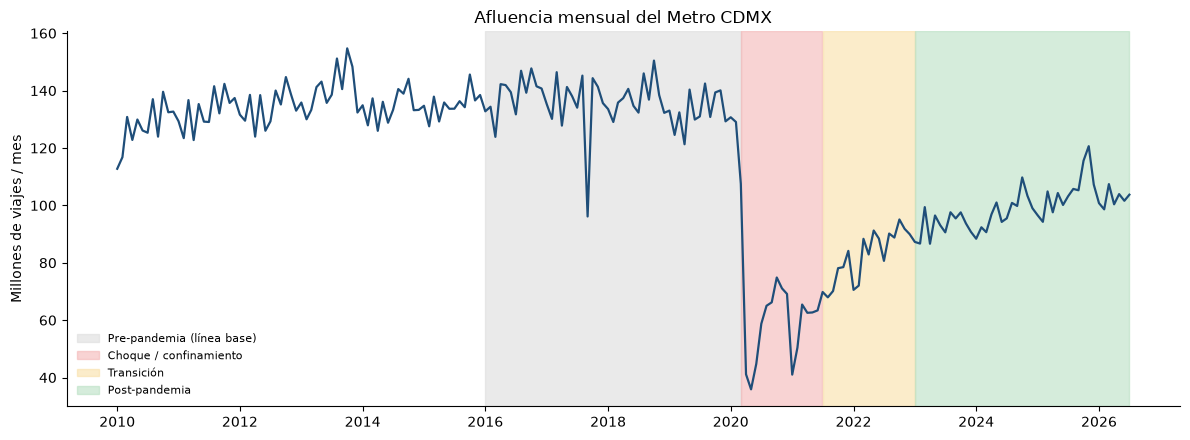

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

mensual = metro.set_index("fecha")["afluencia"].resample("MS").sum() / 1e6
mensual = mensual.iloc[:-1] if metro.fecha.max().day < 28 else mensual  # descarta mes incompleto

colores = ["#dddddd", "#f4b6b6", "#f9e0a8", "#b9e0c3"]
fig, ax = plt.subplots(figsize=(12, 4.5))
for (_, p), c in zip(PERIODOS.iterrows(), colores):
    ax.axvspan(p.inicio, p.fin if pd.notna(p.fin) else mensual.index.max(), color=c, alpha=.6, label=p.periodo)
ax.plot(mensual.index, mensual.values, color="#1f4e79", lw=1.6)
ax.set_ylabel("Millones de viajes / mes")
ax.set_title("Afluencia mensual del Metro CDMX")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(loc="lower left", fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 4.3 Caída y recuperación respecto a 2019
Índice base 100 = promedio mensual de 2019. Permite ver cuánto cayó la afluencia y si ya volvió al nivel previo.

In [10]:
base_2019 = mensual["2019"].mean()
indice = (mensual / base_2019 * 100).rename("indice_2019_100")

anual = indice.groupby(indice.index.year).mean().round(1).to_frame("índice promedio (2019=100)")
anual.loc[2016:]

,índice promedio (2019=100)
fecha,
2016,104.3
2017,101.3
2018,103.3
2019,100.0
2020,56.1
2021,49.8
2022,64.6
2023,69.9
2024,73.5


In [11]:
minimo = indice["2020":].idxmin()
print(f"Mes más bajo: {minimo:%Y-%m} → índice {indice[minimo]:.1f} "
      f"(caída de {100 - indice[minimo]:.1f} % respecto a 2019)")
print(f"Último mes disponible: {indice.index[-1]:%Y-%m} → índice {indice.iloc[-1]:.1f}")

Mes más bajo: 2020-05 → índice 27.0 (caída de 73.0 % respecto a 2019)
Último mes disponible: 2026-07 → índice 78.1


**Advertencia al interpretar.** Parte de la caída posterior a 2021 no se debe a la pandemia sino a **cierres de líneas**: la Línea 12 cerró tras el colapso del 3-may-2021 y la Línea 1 cerró por modernización desde julio de 2022. En la limpieza se marcarán estos cierres para no confundirlos con la falta de recuperación de la demanda.

### 4.4 Segundo problema de calidad: nombres de línea inconsistentes
La columna `linea` tiene 24 valores únicos cuando el Metro tiene 12 líneas. Entre 2021 y 2023 el archivo usa `LÃ­nea 1` (con acento y mojibake) y en los demás años `Linea 1`. Si no se normaliza, cada línea queda partida en dos series.

In [12]:
print(sorted(metro["linea"].unique()))

['Linea 1', 'Linea 12', 'Linea 2', 'Linea 3', 'Linea 4', 'Linea 5', 'Linea 6', 'Linea 7', 'Linea 8', 'Linea 9', 'Linea A', 'Linea B', 'LÃ\xadnea 1', 'LÃ\xadnea 12', 'LÃ\xadnea 2', 'LÃ\xadnea 3', 'LÃ\xadnea 4', 'LÃ\xadnea 5', 'LÃ\xadnea 6', 'LÃ\xadnea 7', 'LÃ\xadnea 8', 'LÃ\xadnea 9', 'LÃ\xadnea A', 'LÃ\xadnea B']


Normalización: se repara la codificación y se unifica la escritura (`Línea` → `Linea`).

In [13]:
metro["linea"] = metro["linea"].map(ftfy.fix_text).str.replace("Línea", "Linea", regex=False)
metro["estacion"] = metro["estacion"].map(ftfy.fix_text)
print(f"Líneas únicas tras normalizar: {metro['linea'].nunique()}")
print(f"Estaciones únicas tras normalizar: {metro['estacion'].nunique()}")

Líneas únicas tras normalizar: 12
Estaciones únicas tras normalizar: 165


Afluencia anual por línea (millones de viajes), ya normalizada. Los ceros y las caídas bruscas de la Línea 12 (2021–2023) y de la Línea 1 (2022–2024) corresponden a cierres, no a baja demanda.

In [14]:
lineas = (metro.assign(anio=metro.fecha.dt.year)
               .pivot_table(index="linea", columns="anio", values="afluencia", aggfunc="sum") / 1e6)
lineas[[a for a in [2019, 2020, 2021, 2022, 2023, 2024, 2025] if a in lineas.columns]].round(1)

anio,2019,2020,2021,2022,2023,2024,2025
linea,,,,,,,
Linea 1,237.5,137.5,128.0,108.0,63.3,67.8,120.1
Linea 12,134.9,78.2,22.1,0.0,46.0,105.0,118.6
Linea 2,269.1,137.7,113.5,177.1,198.8,212.2,217.0
Linea 3,222.4,124.1,107.5,164.1,172.4,172.3,175.1
Linea 4,29.0,16.1,15.9,23.4,26.5,24.9,25.1
Linea 5,78.0,44.0,44.1,56.0,59.9,59.6,56.7
Linea 6,49.9,26.1,23.5,35.7,40.0,38.8,38.8
Linea 7,108.2,55.0,51.9,69.0,78.9,85.6,88.9
Linea 8,133.6,76.4,82.7,115.6,128.2,124.6,118.2


## 5. Siguientes pasos
1. ~~Scripts de descarga por fuente (`src/download/`) con registro en `data/raw/MANIFEST.csv`.~~ Hecho: la cobertura real está en `CONTEXTO.md` §3.0.1.
2. Un notebook de perfil de calidad por dimensión (`01_movilidad`, `02_seguridad`, `03_economia`, `04_pandemia`).
3. Scripts de limpieza (`src/clean/`) y base integrada **alcaldía × mes** en `data/processed/`.

Cada paso queda documentado en la bitácora del informe (`informe/secciones/04_bitacora.tex`).